In [1]:
import psycopg2
import pandas as pd
import networkx as nx
import base58
import matplotlib.pyplot as plt
import re
from math import comb
import matplotlib.dates as mdates
import networkx as nx
from collections import defaultdict
from networkx.algorithms.approximation.clique import large_clique_size
from itertools import combinations
import numpy as np
from networkx.algorithms.coloring import greedy_color
import random
from collections import Counter
import requests
import time
from datetime import datetime, timedelta, timezone

In [2]:
# Connect to PostgreSQL and fetch data
conn = psycopg2.connect(
    dbname="sui_indexer",
    user="postgres",
    password="56904628",
    host="172.26.112.1",
    port=5432
)
conn.autocommit = True
cur = conn.cursor()

write set and conflict graph

In [3]:
cur.execute("""
SELECT
    t.checkpoint_sequence AS checkpoint,
    oc.transaction_digest AS tx,
    oc.address AS object_address,
    c.timestamp AS timestamp
FROM transactions t
JOIN object_changes oc
  ON oc.transaction_digest = t.transaction_digest
JOIN checkpoints c
  ON c.sequence_number = t.checkpoint_sequence
WHERE oc.change_type IS NOT NULL;
""")
write_rows = cur.fetchall()

In [4]:
# graphs[checkpoint] = nx.Graph()
graphs = defaultdict(nx.Graph)

# per checkpoint: object -> list of txs that wrote it
writers_by_cp_obj = defaultdict(lambda: defaultdict(list))

# all txs per checkpoint (so isolated nodes exist)
txs_by_cp = defaultdict(set)

# checkpoint -> timestamp
timestamps_by_cp = {}

for checkpoint, tx, object_address, timestamp in write_rows:
    tx_hex = tx.hex()
    obj_hex = object_address.hex()

    txs_by_cp[checkpoint].add(tx_hex)
    writers_by_cp_obj[checkpoint][obj_hex].append(tx_hex)

    # store timestamp
    if checkpoint not in timestamps_by_cp:
        timestamps_by_cp[checkpoint] = timestamp

# Build graphs
for cp, txs in txs_by_cp.items():
    G = graphs[cp]

    # 1) add all txs as nodes (isolated txs preserved)
    G.add_nodes_from(txs)

    # 2) add edges for shared-write objects
    for writers in writers_by_cp_obj[cp].values():
        writers = list(set(writers))  # de-dup
        if len(writers) < 2:
            continue

        for u, v in combinations(writers, 2):
            G.add_edge(u, v)

# graphs[checkpoint] = NetworkX conflict graph for that checkpoint
print(f"Built {len(graphs)} checkpoint graphs")

Built 73191 checkpoint graphs


density

In [5]:
rows = []

for cp, G in graphs.items():
    rows.append({
        "checkpoint": cp,
        "density": nx.density(G),
        "timestamp": timestamps_by_cp[cp]
    })

df_density = pd.DataFrame(rows)
df_density = df_density.set_index("checkpoint")

timestamp

In [6]:
cur.execute("""
    SELECT
        timestamp,
        user_tx_count,
        system_tx_count
    FROM checkpoints
    ORDER BY timestamp;
""")

rows = cur.fetchall()

df_tx = pd.DataFrame(
    rows,
    columns=["timestamp", "user_tx_count", "system_tx_count"]
)

df_tx["timestamp"] = pd.to_datetime(df_tx["timestamp"], utc=True)
df_tx["tx_count"] = df_tx["user_tx_count"] + df_tx["system_tx_count"]


gas price

In [7]:
cur.execute("""
    SELECT
        c.timestamp,
        AVG(t.gas_price) AS avg_gas_price
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
    GROUP BY c.timestamp
    ORDER BY c.timestamp;
""")

rows = cur.fetchall()

df_price = pd.DataFrame(
    rows,
    columns=["timestamp", "avg_gas_price"]
)

df_price["timestamp"] = pd.to_datetime(df_price["timestamp"], utc=True)
df_price["avg_gas_price"] = pd.to_numeric(df_price["avg_gas_price"], errors="coerce")


In [8]:
df_cp = (
    df_tx[["timestamp", "tx_count"]]
    .merge(df_price, on="timestamp", how="inner")
)

In [9]:
df_tx_price_daily = (
    df_cp
    .assign(day=df_cp["timestamp"].dt.date)
    .groupby("day")
    .agg(
        tx_mean=("tx_count", "mean"),
        tx_std=("tx_count", "std"),
        tx_n=("tx_count", "count"),
        price_mean=("avg_gas_price", "mean"),
        price_std=("avg_gas_price", "std"),
        price_n=("avg_gas_price", "count"),
    )
    .reset_index()
)

# 95% CI
df_tx_price_daily["tx_ci95"] = (
    1.96 * df_tx_price_daily["tx_std"] / np.sqrt(df_tx_price_daily["tx_n"])
)
df_tx_price_daily["price_ci95"] = (
    1.96 * df_tx_price_daily["price_std"] / np.sqrt(df_tx_price_daily["price_n"])
)

df_tx_price_daily["day"] = pd.to_datetime(df_tx_price_daily["day"])

# numeric safety
cols = ["tx_mean", "tx_ci95", "price_mean", "price_ci95"]
df_tx_price_daily[cols] = df_tx_price_daily[cols].astype(float)


lcc and largest clique

In [10]:
largest_cc = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        continue
    largest_cc[cp] = len(max(nx.connected_components(G), key=len))

df_lcc = pd.DataFrame(
    [
        (cp, lcc, timestamps_by_cp[cp])
        for cp, lcc in largest_cc.items()
    ],
    columns=["checkpoint", "largest_cc", "timestamp"]
)

df_lcc["timestamp"] = pd.to_datetime(df_lcc["timestamp"], utc=True)

In [11]:
clique_sizes = {}

for cp, G in graphs.items():
    if G.number_of_nodes() == 0:
        clique_sizes[cp] = 0
        continue

    # Fast greedy heuristic for max clique size
    clique_sizes[cp] = large_clique_size(G)

df_clique = pd.DataFrame(
    [
        (cp, c, timestamps_by_cp[cp])
        for cp, c in clique_sizes.items()
    ],
    columns=["checkpoint", "clique_size", "timestamp"]
)

df_clique["timestamp"] = pd.to_datetime(df_clique["timestamp"], utc=True)

Gas used and highest speed up

In [12]:
cur.execute("""
    SELECT
        t.checkpoint_sequence AS checkpoint,
        t.gas_used,
        c.timestamp
    FROM transactions t
    JOIN checkpoints c
        ON t.checkpoint_sequence = c.sequence_number
""")

rows = cur.fetchall()

df_tx_gas = pd.DataFrame(
    rows,
    columns=["checkpoint", "gas_used", "timestamp"]
)

df_tx_gas["checkpoint"] = df_tx_gas["checkpoint"].astype(int)
df_tx_gas["gas_used"] = pd.to_numeric(df_tx_gas["gas_used"], errors="coerce")
df_tx_gas["timestamp"] = pd.to_datetime(df_tx_gas["timestamp"], utc=True)

# ---------- build df_block from df_tx ----------

df_block = (
    df_tx_gas
    .groupby("checkpoint")
    .agg(
        block_gas=("gas_used", "sum"),
        max_tx_gas=("gas_used", "max"),
        timestamp=("timestamp", "first"),
    )
    .reset_index()
)

In [13]:
# ---------- 1) prepare basics ----------

df_block["checkpoint"] = df_block["checkpoint"].astype(int)
df_block["timestamp"] = pd.to_datetime(df_block["timestamp"], utc=True)

df_lcc["checkpoint"] = df_lcc["checkpoint"].astype(int)
df_clique["checkpoint"] = df_clique["checkpoint"].astype(int)

df_tx_gas["checkpoint"] = df_tx_gas["checkpoint"].astype(int)
df_tx_gas["gas_used"] = pd.to_numeric(df_tx_gas["gas_used"], errors="coerce")

# tx count per checkpoint
df_tx_count = (
    df_tx_gas
    .groupby("checkpoint")
    .size()
    .rename("tx_count")
    .reset_index()
)

# ---------- 2) merge everything ----------

df = (
    df_block
    .merge(df_lcc, on="checkpoint", how="inner")
    .merge(df_clique, on="checkpoint", how="inner")
    .merge(df_tx_count, on="checkpoint", how="inner")
)

# ---------- 3) approximate CC / clique gas ----------

df["avg_tx_gas"] = df["block_gas"] / df["tx_count"]
df["cc_gas"] = df["largest_cc"] * df["avg_tx_gas"]
df["clique_gas"] = df["clique_size"] * df["avg_tx_gas"]

# ---------- 4) daily aggregation + 95% CI ----------

metrics = {
    "block_gas": "block_gas",
    "cc_gas": "cc_gas",
    "clique_gas": "clique_gas",
    "max_tx_gas": "max_tx_gas",
}

df_gas_daily = (
    df
    .assign(day=df["timestamp"].dt.date)
    .groupby("day")[list(metrics.values())]
    .agg(["mean", "std", "count"])
)

# flatten columns
df_gas_daily.columns = ["_".join(c) for c in df_gas_daily.columns]
df_gas_daily = df_gas_daily.reset_index()

# compute 95% CI
for m in metrics.values():
    df_gas_daily[f"{m}_ci95"] = (
        1.96 * df_gas_daily[f"{m}_std"] / np.sqrt(df_gas_daily[f"{m}_count"])
    )

df_gas_daily["day"] = pd.to_datetime(df_gas_daily["day"])

# numeric safety
cols = [c for c in df_gas_daily.columns if c != "day"]
df_gas_daily[cols] = df_gas_daily[cols].astype(float)

# optional cleanup
df_gas_daily = df_gas_daily.dropna(
    subset=[f"{m}_mean" for m in metrics.values()]
)


In [14]:
# ---------- build df_speedup_daily ----------

df_speedup_daily = pd.DataFrame()
df_speedup_daily["day"] = df_gas_daily["day"]

# lower bound: total / max CC
df_speedup_daily["speedup_lb"] = (
    df_gas_daily["block_gas_mean"] / df_gas_daily["cc_gas_mean"]
)

# upper bound: total / max clique
df_speedup_daily["speedup_ub"] = (
    df_gas_daily["block_gas_mean"] / df_gas_daily["clique_gas_mean"]
)

# ---------- 95% CI via delta method ----------

def ratio_ci(mean_a, ci_a, mean_b, ci_b):
    ratio = mean_a / mean_b
    rel_err = np.sqrt((ci_a / mean_a) ** 2 + (ci_b / mean_b) ** 2)
    return ratio * rel_err

df_speedup_daily["speedup_lb_ci95"] = ratio_ci(
    df_gas_daily["block_gas_mean"],
    df_gas_daily["block_gas_ci95"],
    df_gas_daily["cc_gas_mean"],
    df_gas_daily["cc_gas_ci95"],
)

df_speedup_daily["speedup_ub_ci95"] = ratio_ci(
    df_gas_daily["block_gas_mean"],
    df_gas_daily["block_gas_ci95"],
    df_gas_daily["clique_gas_mean"],
    df_gas_daily["clique_gas_ci95"],
)

# numeric safety
cols = ["speedup_lb", "speedup_lb_ci95", "speedup_ub", "speedup_ub_ci95"]
df_speedup_daily[cols] = df_speedup_daily[cols].astype(float)

# optional cleanup
df_speedup_daily = df_speedup_daily.replace([np.inf, -np.inf], np.nan)
df_speedup_daily = df_speedup_daily.dropna(subset=cols)


## Parallelism vs Gas Used (Periods of Activity)

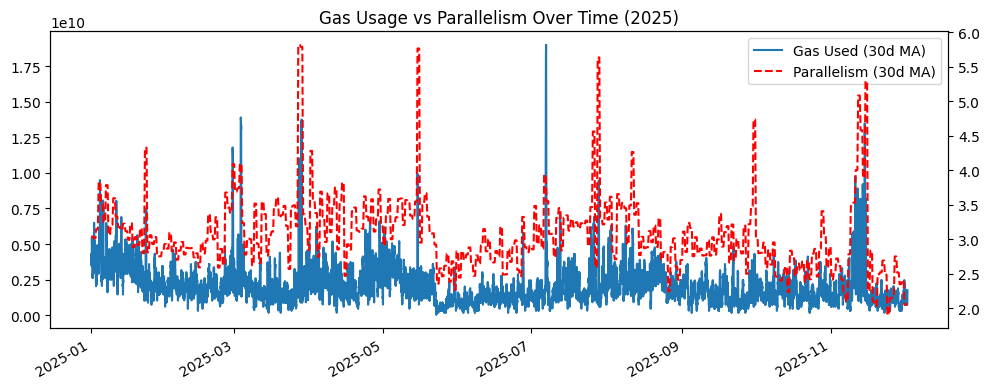

In [109]:
# copy and prepare dataframe
df_plot = df_block.copy()
df_plot["timestamp"] = pd.to_datetime(df_plot["timestamp"])

# merge gas used with speedup
df_plot = df_plot.merge(
    df_speedup_daily[["day", "speedup_lb"]],
    left_on=df_plot["timestamp"].dt.date,
    right_on="day",
    how="inner"
)

df_plot = df_plot[df_plot["timestamp"].dt.year == 2025]

df_plot["gas_used_ma30"] = df_plot["block_gas"].rolling(30).mean()
df_plot["speedup_ma30"] = df_plot["speedup_lb"].rolling(30).mean()

fig, ax1 = plt.subplots(figsize=(10,4))
ax2 = ax1.twinx()

ax1.plot(
    df_plot["timestamp"],
    df_plot["gas_used_ma30"],
    label="Gas Used (30d MA)"
)

ax2.plot(
    df_plot["timestamp"],
    df_plot["speedup_ma30"],
    linestyle="--",
    color="red",
    label="Parallelism (30d MA)"
)

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs Parallelism Over Time (2025)")
plt.tight_layout()
plt.show()

In [110]:
df = df_plot[["gas_used_ma30", "speedup_ma30"]].dropna()
print(df.corr().iloc[0,1])

0.4108696352637371


# CoinMarketApi Data

In [15]:
df_btc_2023 = pd.read_csv('Bitcoin_01_01_2023-01_01_2024_historical_data_coinmarketcap.csv', sep=";")
df_btc_2024 = pd.read_csv('Bitcoin_01_01_2024-01_01_2025_historical_data_coinmarketcap.csv', sep=";")
df_btc_2025 = pd.read_csv('Bitcoin_01_01_2025-01_01_2026_historical_data_coinmarketcap.csv', sep=";")

df_btc = (
    pd.concat([df_btc_2023, df_btc_2024, df_btc_2025], ignore_index=True)
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"])
)

df_eth_2023 = pd.read_csv("Ethereum_01_01_2023-01_01_2024_historical_data_coinmarketcap.csv", sep=";")
df_eth_2024 = pd.read_csv("Ethereum_01_01_2024-01_01_2025_historical_data_coinmarketcap.csv", sep=";")
df_eth_2025 = pd.read_csv("Ethereum_01_01_2025-01_01_2026_historical_data_coinmarketcap.csv", sep=";")

df_eth = (
    pd.concat([df_eth_2023, df_eth_2024, df_eth_2025], ignore_index=True)
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"])
)

df_sui_2023 = pd.read_csv('Sui_01_01_2023-01_01_2024_historical_data_coinmarketcap.csv', sep=";")
df_sui_2024 = pd.read_csv('Sui_01_01_2024-01_01_2025_historical_data_coinmarketcap.csv', sep=";")
df_sui_2025 = pd.read_csv('Sui_01_01_2025-01_01_2026_historical_data_coinmarketcap.csv', sep=";")

df_sui = (
    pd.concat([df_sui_2023, df_sui_2024, df_sui_2025], ignore_index=True)
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"])
)

In [16]:
# --- BTC daily ---
df_btc["timestamp"] = pd.to_datetime(df_btc["timestamp"], utc=True)

df_btc_daily = (
    df_btc
    .assign(day=df_btc["timestamp"].dt.floor("D"))     # UTC midnight
    .assign(
        btc_price=pd.to_numeric(df_btc["close"], errors="coerce"),
        btc_market_cap=pd.to_numeric(df_btc["marketCap"], errors="coerce"),
    )
    .loc[:, ["day", "btc_price", "btc_market_cap"]]
)

# --- ETH daily ---
df_eth["timestamp"] = pd.to_datetime(df_eth["timestamp"], utc=True)

df_eth_daily = (
    df_eth
    .assign(day=df_eth["timestamp"].dt.floor("D"))     # UTC midnight
    .assign(
        eth_price=pd.to_numeric(df_eth["close"], errors="coerce"),
        eth_market_cap=pd.to_numeric(df_eth["marketCap"], errors="coerce"),
    )
    .loc[:, ["day", "eth_price", "eth_market_cap"]]
)

# --- SUI daily ---
df_sui["timestamp"] = pd.to_datetime(df_sui["timestamp"], utc=True)

df_sui_daily = (
    df_sui
    .assign(day=df_sui["timestamp"].dt.floor("D"))     # UTC midnight
    .assign(
        sui_price=pd.to_numeric(df_sui["close"], errors="coerce"),
        sui_market_cap=pd.to_numeric(df_sui["marketCap"], errors="coerce"),
    )
    .loc[:, ["day", "sui_price", "sui_market_cap"]]
)

In [17]:
# --- SUI/BTC ---
df_btc_sui = (
    df_sui_daily
    .merge(df_btc_daily[["day", "btc_price"]], on="day", how="inner")
    .assign(sui_btc = lambda x: x["sui_price"] / x["btc_price"])
    .loc[:, ["day", "sui_btc"]]
)

# --- SUI/ETH ---
df_eth_sui = (
    df_sui_daily
    .merge(df_eth_daily[["day", "eth_price"]], on="day", how="inner")
    .assign(sui_eth = lambda x: x["sui_price"] / x["eth_price"])
    .loc[:, ["day", "sui_eth"]]
)

In [67]:
# --- Daily gas used from df_block ---
df_block["timestamp"] = pd.to_datetime(df_block["timestamp"], utc=True)

df_gas_daily = (
    df_block
    .assign(day=df_block["timestamp"].dt.date)
    .groupby("day", as_index=False)
    .agg(block_gas_mean=("block_gas", "mean"))
)

# make sure all day columns match
df_gas_daily["day"] = pd.to_datetime(df_gas_daily["day"]).dt.date
df_sui_daily["day"] = pd.to_datetime(df_sui_daily["day"]).dt.date
df_btc_sui["day"] = pd.to_datetime(df_btc_sui["day"]).dt.date
df_eth_sui["day"] = pd.to_datetime(df_eth_sui["day"]).dt.date

# --- Merge gas used with SUI price ---
df_merged_gas_sui = (
    df_sui_daily[["day", "sui_price", "sui_market_cap"]]
    .merge(
        df_gas_daily[["day", "block_gas_mean"]],
        on="day",
        how="inner"
    )
    .sort_values("day")
)

# --- Merge gas used with SUI/BTC ratio ---
df_merged_gas_btc_sui = (
    df_btc_sui[["day", "sui_btc"]]
    .merge(
        df_gas_daily[["day", "block_gas_mean"]],
        on="day",
        how="inner"
    )
    .sort_values("day")
)

# --- Merge gas used with SUI/ETH ratio ---
df_merged_gas_eth_sui = (
    df_eth_sui[["day", "sui_eth"]]
    .merge(
        df_gas_daily[["day", "block_gas_mean"]],
        on="day",
        how="inner"
    )
    .sort_values("day")
)

## Gas Used vs SUI Price

In [111]:
df_plot = df_merged_gas_sui.copy()
df_plot["day"] = pd.to_datetime(df_plot["day"])

# normalize
df_plot["gas_used_norm"] = df_plot["block_gas_mean"] / df_plot["block_gas_mean"].dropna().iloc[0] * 100
df_plot["sui_price_norm"] = df_plot["sui_price"] / df_plot["sui_price"].dropna().iloc[0] * 100

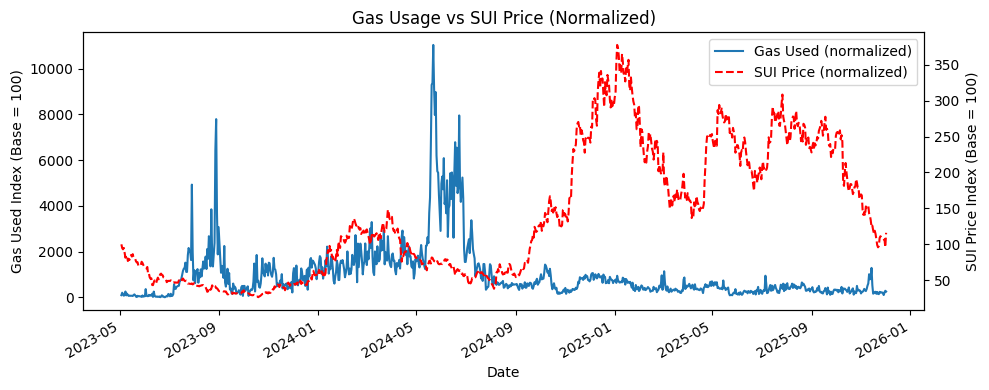

In [112]:
fig, ax1 = plt.subplots(figsize=(10,4))

# Gas used (left axis)
ax1.plot(
    df_plot["day"],
    df_plot["gas_used_norm"],
    label="Gas Used (normalized)"
)
ax1.set_ylabel("Gas Used Index (Base = 100)")
ax1.set_xlabel("Date")

# SUI price (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_plot["day"],
    df_plot["sui_price_norm"],
    linestyle="--",
    color="red",
    label="SUI Price (normalized)"
)
ax2.set_ylabel("SUI Price Index (Base = 100)")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs SUI Price (Normalized)")
plt.tight_layout()
plt.show()

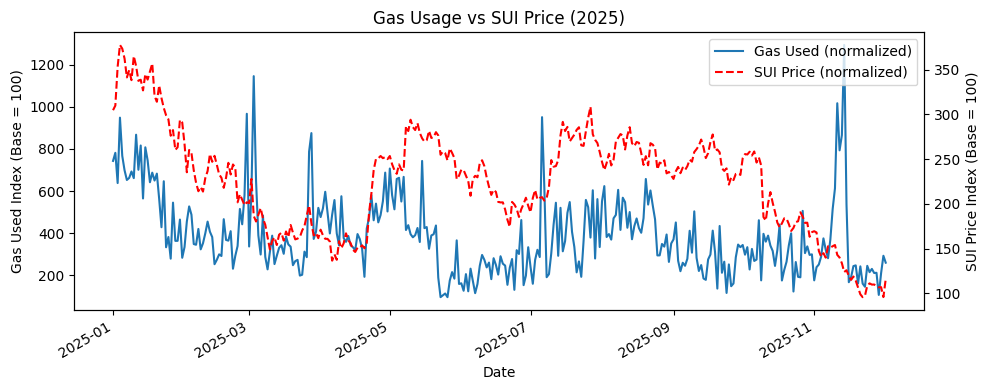

In [113]:
df_plot = df_plot[df_plot["day"].dt.year == 2025]

fig, ax1 = plt.subplots(figsize=(10,4))

# Gas used (left axis)
ax1.plot(
    df_plot["day"],
    df_plot["gas_used_norm"],
    label="Gas Used (normalized)"
)
ax1.set_ylabel("Gas Used Index (Base = 100)")
ax1.set_xlabel("Date")

# SUI price (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_plot["day"],
    df_plot["sui_price_norm"],
    linestyle="--",
    color="red",
    label="SUI Price (normalized)"
)
ax2.set_ylabel("SUI Price Index (Base = 100)")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs SUI Price (2025)")
plt.tight_layout()
plt.show()

In [114]:
df = df_plot[["gas_used_norm", "sui_price_norm"]].dropna()
print(df.corr().iloc[0,1])

0.3026911445080592


0.3^2 = 9% of variance in gas used is explained by SUI price

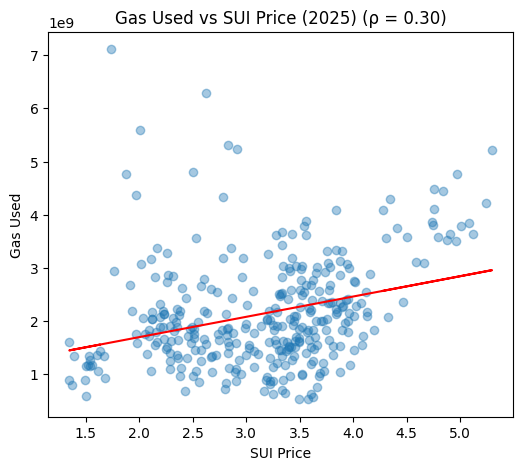

In [115]:
x = df_plot["sui_price"]
y = df_plot["block_gas_mean"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.4)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", label="Regression line")



plt.xlabel("SUI Price")
plt.ylabel("Gas Used")
plt.title("Gas Used vs SUI Price (2025) (ρ = 0.30)")

plt.show()

In [116]:
df_plot["corr_ma30"] = (
    df_plot["gas_used_norm"]
    .rolling(30)
    .corr(df_plot["sui_price_norm"])
)

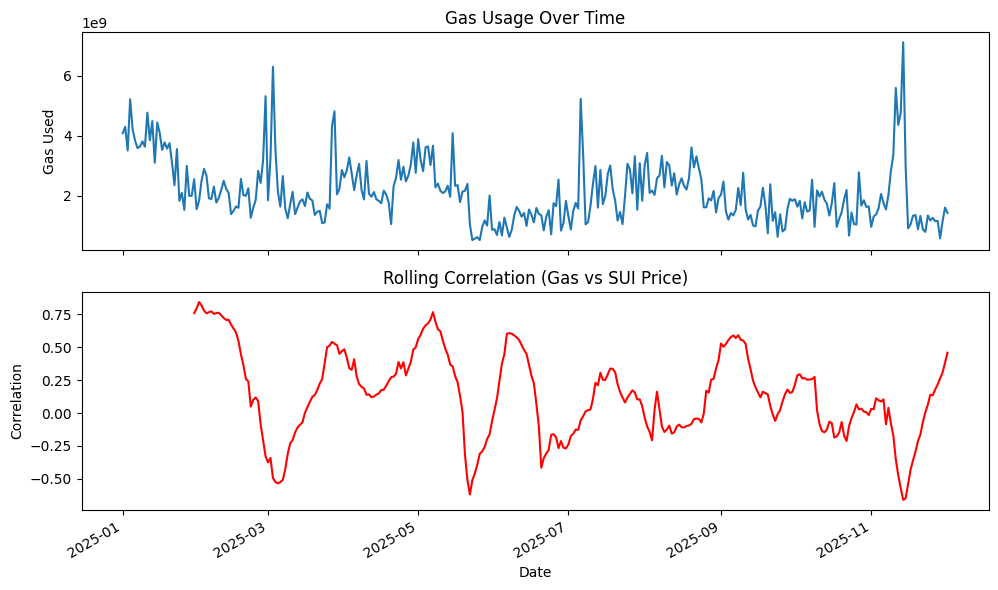

In [117]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10,6), sharex=True
)

# panel 1: gas used
ax1.plot(df_plot["day"], df_plot["block_gas_mean"])
ax1.set_ylabel("Gas Used")
ax1.set_title("Gas Usage Over Time")

# panel 2: rolling correlation
ax2.plot(df_plot["day"], df_plot["corr_ma30"], color="red")
ax2.set_ylabel("Correlation")
ax2.set_xlabel("Date")
ax2.set_title("Rolling Correlation (Gas vs SUI Price)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Gas Used vs SUI/BTC

In [125]:
df_plot = df_merged_gas_btc_sui.copy()
df_plot["day"] = pd.to_datetime(df_plot["day"])

# normalize
df_plot["gas_used_norm"] = df_plot["block_gas_mean"] / df_plot["block_gas_mean"].dropna().iloc[0] * 100
df_plot["sui_btc_norm"] = df_plot["sui_btc"] / df_plot["sui_btc"].dropna().iloc[0] * 100

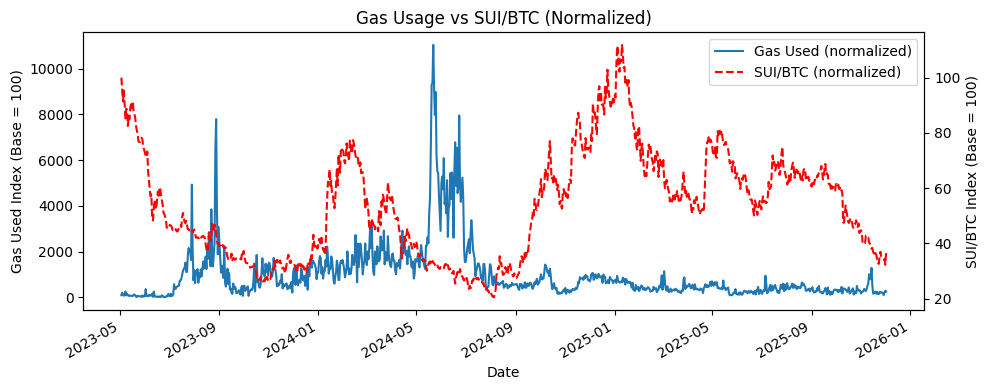

In [126]:
fig, ax1 = plt.subplots(figsize=(10,4))

# Gas used (left axis)
ax1.plot(
    df_plot["day"],
    df_plot["gas_used_norm"],
    label="Gas Used (normalized)"
)
ax1.set_ylabel("Gas Used Index (Base = 100)")
ax1.set_xlabel("Date")

# SUI price (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_plot["day"],
    df_plot["sui_btc_norm"],
    linestyle="--",
    color="red",
    label="SUI/BTC (normalized)"
)
ax2.set_ylabel("SUI/BTC Index (Base = 100)")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs SUI/BTC (Normalized)")
plt.tight_layout()
plt.show()

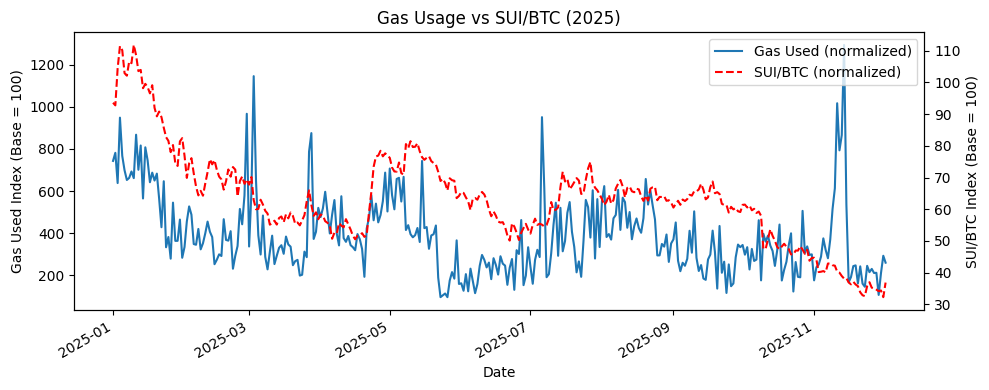

In [127]:
df_plot = df_plot[df_plot["day"].dt.year == 2025]

fig, ax1 = plt.subplots(figsize=(10,4))

# Gas used (left axis)
ax1.plot(
    df_plot["day"],
    df_plot["gas_used_norm"],
    label="Gas Used (normalized)"
)
ax1.set_ylabel("Gas Used Index (Base = 100)")
ax1.set_xlabel("Date")

# SUI price (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_plot["day"],
    df_plot["sui_btc_norm"],
    linestyle="--",
    color="red",
    label="SUI/BTC (normalized)"
)
ax2.set_ylabel("SUI/BTC Index (Base = 100)")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs SUI/BTC (2025)")
plt.tight_layout()
plt.show()

In [128]:
df = df_plot[["gas_used_norm", "sui_btc_norm"]].dropna()
print(df.corr().iloc[0,1])

0.42801354881853176


0.42^2 = 18% of variance in gas used is explained by SUI/BTC

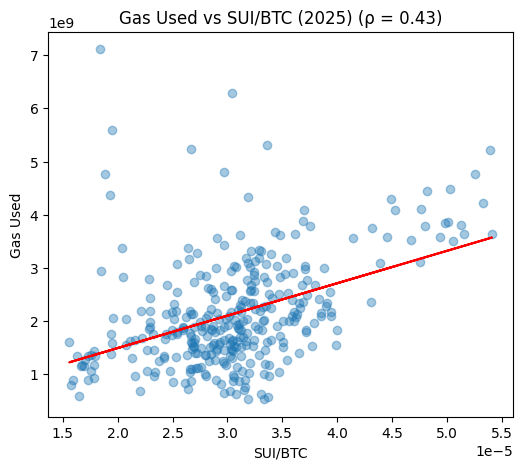

In [129]:
x = df_plot["sui_btc"]
y = df_plot["block_gas_mean"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.4)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", label="Regression line")


plt.xlabel("SUI/BTC")
plt.ylabel("Gas Used")
plt.title("Gas Used vs SUI/BTC (2025) (ρ = 0.43)")

plt.show()

In [130]:
df_plot["corr_btc_ma30"] = (
    df_plot["gas_used_norm"]
    .rolling(30)
    .corr(df_plot["sui_btc_norm"])
)

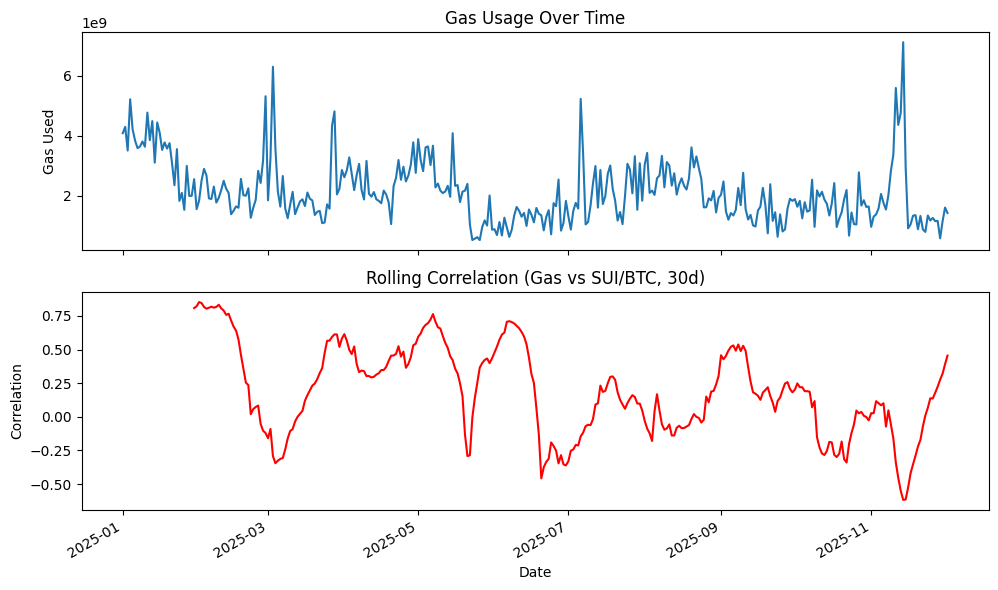

In [131]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10,6), sharex=True
)

# Panel 1: gas usage
ax1.plot(df_plot["day"], df_plot["block_gas_mean"])
ax1.set_ylabel("Gas Used")
ax1.set_title("Gas Usage Over Time")

# Panel 2: rolling correlation (gas vs SUI/BTC)
ax2.plot(df_plot["day"], df_plot["corr_btc_ma30"], color="red")
ax2.set_ylabel("Correlation")
ax2.set_xlabel("Date")
ax2.set_title("Rolling Correlation (Gas vs SUI/BTC, 30d)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Gas Used vs SUI/ETH

In [118]:
df_plot = df_merged_gas_eth_sui.copy()
df_plot["day"] = pd.to_datetime(df_plot["day"])

# normalize
df_plot["gas_used_norm"] = df_plot["block_gas_mean"] / df_plot["block_gas_mean"].dropna().iloc[0] * 100
df_plot["sui_eth_norm"] = df_plot["sui_eth"] / df_plot["sui_eth"].dropna().iloc[0] * 100

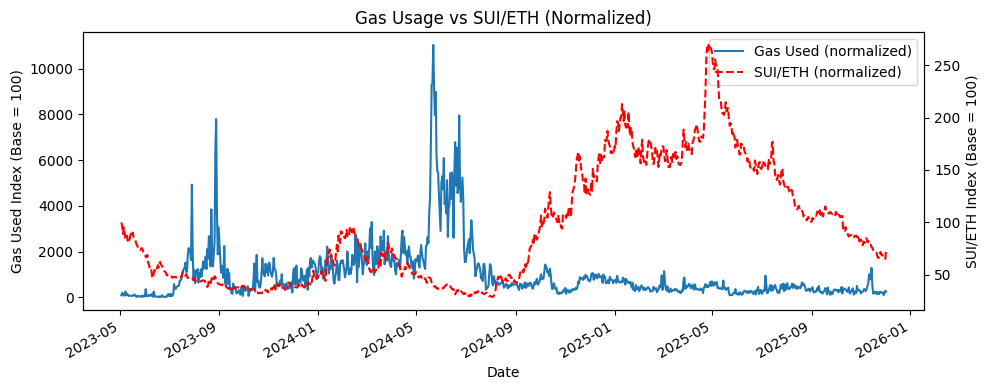

In [119]:
fig, ax1 = plt.subplots(figsize=(10,4))

# Gas used (left axis)
ax1.plot(
    df_plot["day"],
    df_plot["gas_used_norm"],
    label="Gas Used (normalized)"
)
ax1.set_ylabel("Gas Used Index (Base = 100)")
ax1.set_xlabel("Date")

# SUI price (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_plot["day"],
    df_plot["sui_eth_norm"],
    linestyle="--",
    color="red",
    label="SUI/ETH (normalized)"
)
ax2.set_ylabel("SUI/ETH Index (Base = 100)")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs SUI/ETH (Normalized)")
plt.tight_layout()
plt.show()

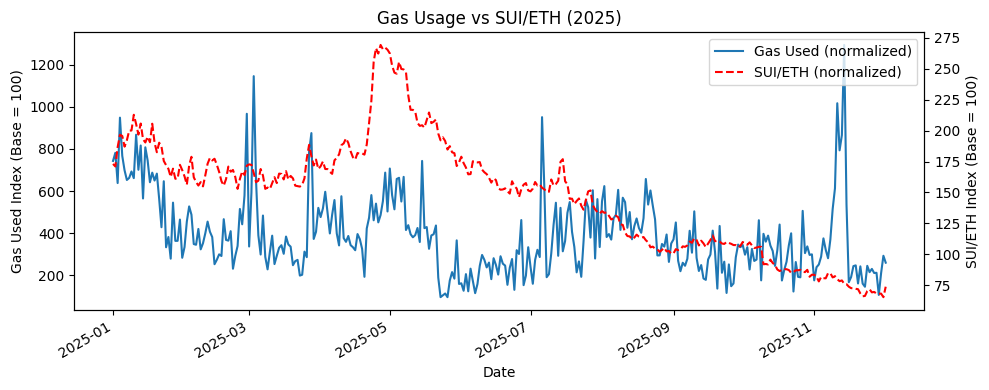

In [120]:
df_plot = df_plot[df_plot["day"].dt.year == 2025]

fig, ax1 = plt.subplots(figsize=(10,4))

# Gas used (left axis)
ax1.plot(
    df_plot["day"],
    df_plot["gas_used_norm"],
    label="Gas Used (normalized)"
)
ax1.set_ylabel("Gas Used Index (Base = 100)")
ax1.set_xlabel("Date")

# SUI price (right axis)
ax2 = ax1.twinx()
ax2.plot(
    df_plot["day"],
    df_plot["sui_eth_norm"],
    linestyle="--",
    color="red",
    label="SUI/ETH (normalized)"
)
ax2.set_ylabel("SUI/ETH Index (Base = 100)")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.autofmt_xdate()
plt.title("Gas Usage vs SUI/ETH (2025)")
plt.tight_layout()
plt.show()

In [121]:
df = df_plot[["gas_used_norm", "sui_eth_norm"]].dropna()
print(df.corr().iloc[0,1])

0.3007783086576717


0.3^2 = 9% of variance in gas used is explained by SUI/ETH

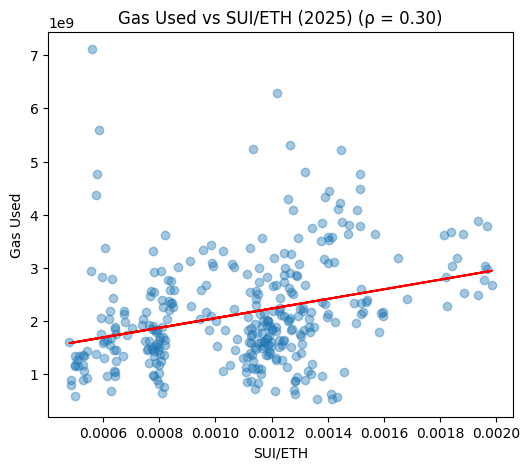

In [122]:
x = df_plot["sui_eth"]
y = df_plot["block_gas_mean"]

plt.figure(figsize=(6,5))

plt.scatter(x, y, alpha=0.4)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", label="Regression line")


plt.xlabel("SUI/ETH")
plt.ylabel("Gas Used")
plt.title("Gas Used vs SUI/ETH (2025) (ρ = 0.30)")

plt.show()

In [123]:
df_plot["corr_eth_ma30"] = (
    df_plot["gas_used_norm"]
    .rolling(30)
    .corr(df_plot["sui_eth_norm"])
)

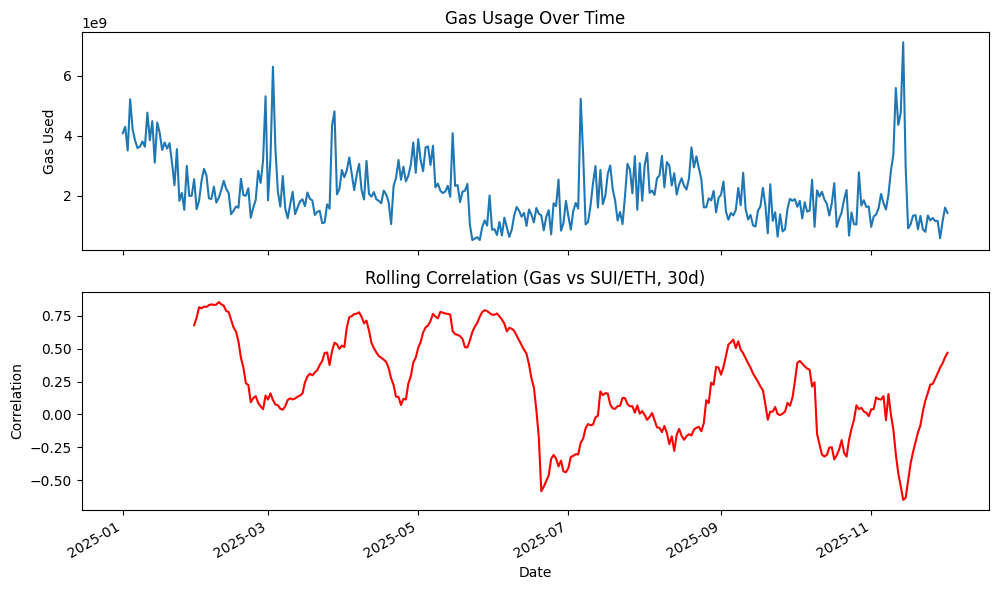

In [124]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10,6), sharex=True
)

# Panel 1: gas used
ax1.plot(df_plot["day"], df_plot["block_gas_mean"])
ax1.set_ylabel("Gas Used")
ax1.set_title("Gas Usage Over Time")

# Panel 2: rolling correlation (gas vs SUI/ETH)
ax2.plot(df_plot["day"], df_plot["corr_eth_ma30"], color="red")
ax2.set_ylabel("Correlation")
ax2.set_xlabel("Date")
ax2.set_title("Rolling Correlation (Gas vs SUI/ETH, 30d)")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()